In [3]:
import scanpy as sc
import anndata as ad
from scipy import io
import scipy
from scipy.sparse import coo_matrix, csr_matrix
import numpy as np
import os
import pickle
import pandas as pd
import matplotlib.pyplot as pl
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import matplotlib as mpl
import matplotlib as mp
mpl.rcParams['pdf.fonttype'] = 42

sc.settings.set_figure_params(facecolor='white', dpi=100, frameon=False)

import matplotlib.colors

In [23]:
# load matrix
X = io.mmread("tcga.counts.mtx")

# create anndata object
adata = ad.AnnData(
    X=X.transpose().tocsr()
)

# load metadata
cell_meta = pd.read_csv("tcga.metadata.csv", low_memory=False)
cell_meta = cell_meta.drop('TP63', axis=1)

# load gene names
with open("tcga.gene.names.csv", 'r') as f:
    gene_names = f.read().splitlines()

# set anndata observations and index obs by barcodes, var by gene names
adata.obs = cell_meta
adata.obs.index = adata.obs['barcode']
adata.var.index = gene_names

In [24]:
adata

AnnData object with n_obs × n_vars = 132 × 20530
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'samples', 'cg11964474', 'cg25738236', 'cg06973652', 'cg05815247', 'cg10609677', 'cg27581762', 'cg19442659', 'cg24900425', 'cg26370022', 'cg11529738', 'cg19454999', 'cg25288140', 'cg14687474', 'cg18372208', 'cg16006004', 'cg14947218', 'cg02286533', 'cg06001716', 'cg26276233', 'cg25067162', 'cg09831010', 'cg12182452', 'cg11126247', 'cg10893007', 'cg20760063', 'cg26891576', 'cg09441966', 'cg17301289', 'cg04658354', 'cg04110421', 'cg21253966', 'cg16630982', 'cg16963062', 'cg15419295', 'cg20187250', 'cg24806953', 'cg08993267', 'cg08386886', 'cg19088651', 'cg19531713', 'cg12984107', 'cg04582861', 'cg13782816', 'cg07054526', 'cg18830083', 'cg16919093', 'cg16029534', 'cg01879757', 'histological_type', 'PAM50Call_RNAseq', 'gender', 'distant_metastasis_present_ind2', 'TP53..average.', 'BRCA1..average.', 'anatomic_neoplasm_subdivision', 'initial_weight', 'pathologic_stage', 'sample_type', 'final

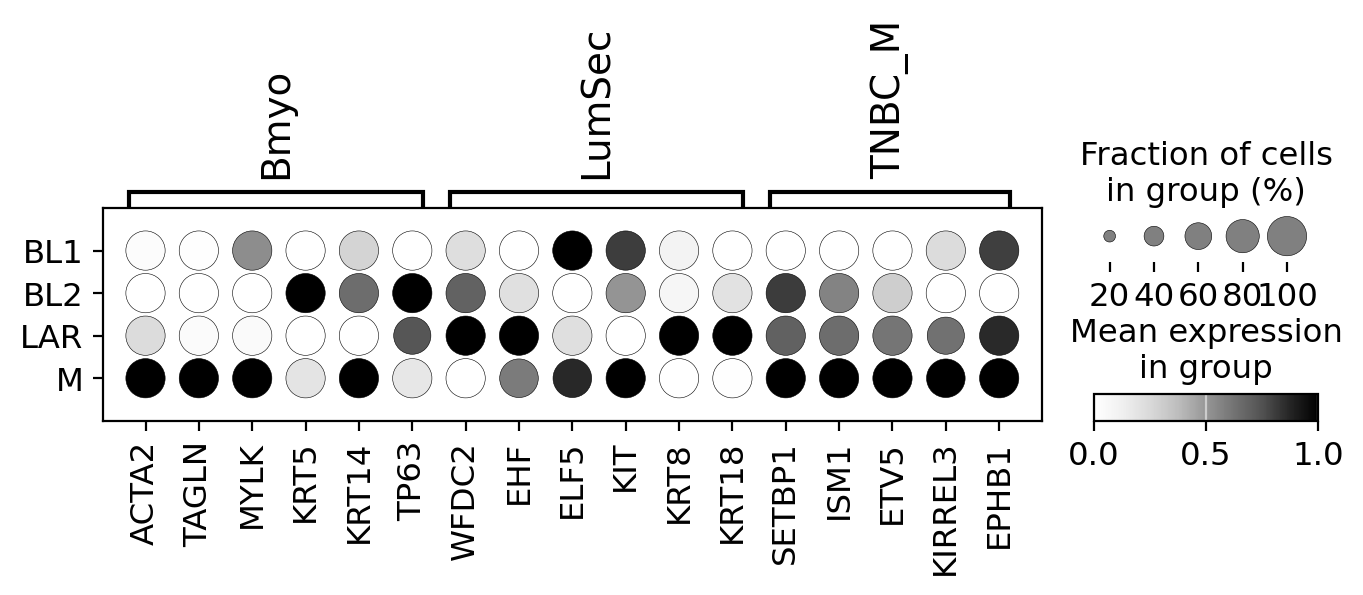

In [7]:
sub=adata[~adata.obs['final_subtype'].isin(['UNC'])]
marker_genes = {
    "Bmyo": ["ACTA2","TAGLN","MYLK","KRT5","KRT14","TP63"],
    "LumSec": ["WFDC2","EHF","ELF5","KIT","KRT8","KRT18"],
    "TNBC_M":["SETBP1","ISM1","ETV5","KIRREL3","EPHB1"]}


sc.pl.dotplot(sub, marker_genes, groupby="final_subtype",standard_scale="var",swap_axes=False,cmap='Greys',save='_tcga_mesenchymal_canonical.pdf')

In [ ]:
# Take out GSTM5

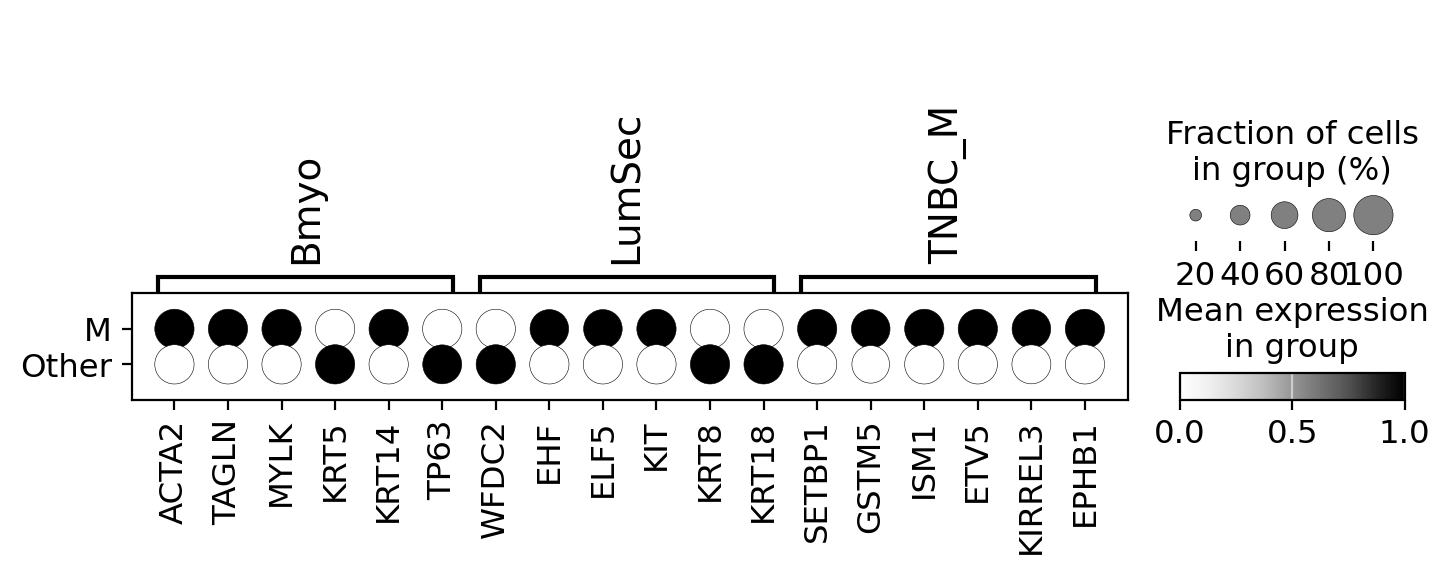

In [29]:
marker_genes = {
    "Bmyo": ["ACTA2","TAGLN","MYLK","KRT5","KRT14","TP63"],
    "LumSec": ["WFDC2","EHF","ELF5","KIT","KRT8","KRT18"],
    "TNBC_M":["SETBP1","GSTM5","ISM1","ETV5","KIRREL3","EPHB1"]}


sc.pl.dotplot(adata, marker_genes, groupby="subtype_other",standard_scale="var",swap_axes=False,cmap='Greys',save='_tcga_mesenchymal_canonical.pdf')

In [30]:
adata.write('tcga.h5ad')

# Merge with Nathanson so that 1 metadata table can be exported

In [4]:
adata=sc.read_h5ad('tcga.h5ad')

In [11]:
#make a dataset column for TCGA
adata.obs['dataset']="TCGA"

In [22]:
adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'samples', 'cg11964474',
       'cg25738236', 'cg06973652', 'cg05815247', 'cg10609677', 'cg27581762',
       'cg19442659', 'cg24900425', 'cg26370022', 'cg11529738', 'cg19454999',
       'cg25288140', 'cg14687474', 'cg18372208', 'cg16006004', 'cg14947218',
       'cg02286533', 'cg06001716', 'cg26276233', 'cg25067162', 'cg09831010',
       'cg12182452', 'cg11126247', 'cg10893007', 'cg20760063', 'cg26891576',
       'cg09441966', 'cg17301289', 'cg04658354', 'cg04110421', 'cg21253966',
       'cg16630982', 'cg16963062', 'cg15419295', 'cg20187250', 'cg24806953',
       'cg08993267', 'cg08386886', 'cg19088651', 'cg19531713', 'cg12984107',
       'cg04582861', 'cg13782816', 'cg07054526', 'cg18830083', 'cg16919093',
       'cg16029534', 'cg01879757', 'histological_type', 'PAM50Call_RNAseq',
       'gender', 'distant_metastasis_present_ind2', 'TP53..average.',
       'BRCA1..average.', 'anatomic_neoplasm_subdivision', 'initial_weight',
       '

In [7]:
brca=sc.read_h5ad('/share/crsp/lab/dalawson/share/BRCA_Nathanson_bulk/final_brca1_wt_tumors.h5ad')

In [13]:
brca.obs['dataset']="Nathanson_Lab"

In [23]:
brca.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Group', 'Receptor',
       'Mutation', 'Primary_Recurrent', 'Treatment', 'batch', 'final_subtype',
       'wap_cre_deg_all_cells1', 'subtype_M_or_other',
       'blg_cre_deg_all_cells1', 'blg_cre_deg1', 'misc', 'mouse_blg_like',
       'subtype_mutation', 'subtype_mutation_other', 'wap_cre_deg1', 'tcga1',
       'barcode', 'dataset'],
      dtype='object')

In [10]:
brca.obs['Mutation'].value_counts()

Mutation
BRCA1    35
WT       16
Name: count, dtype: int64

In [26]:
adata_merged = ad.concat([brca,adata], join="outer")

In [28]:
df = adata_merged.obs

In [29]:
df = df[['dataset', 'final_subtype', 'Mutation', 'blg_cre_deg1', 'wap_cre_deg1', 'tcga1']]

In [31]:
df.to_csv("Table_5_TCGA_Nathanson_subtyped_samples.csv")